<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:73: SyntaxWarning: invalid escape sequence '\p'
C:\Users\oribr\AppData\Local\Temp\ipykernel_38448\1284982705.py:73: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv('..\\results\part2_final(100)\\bert_scores.csv')


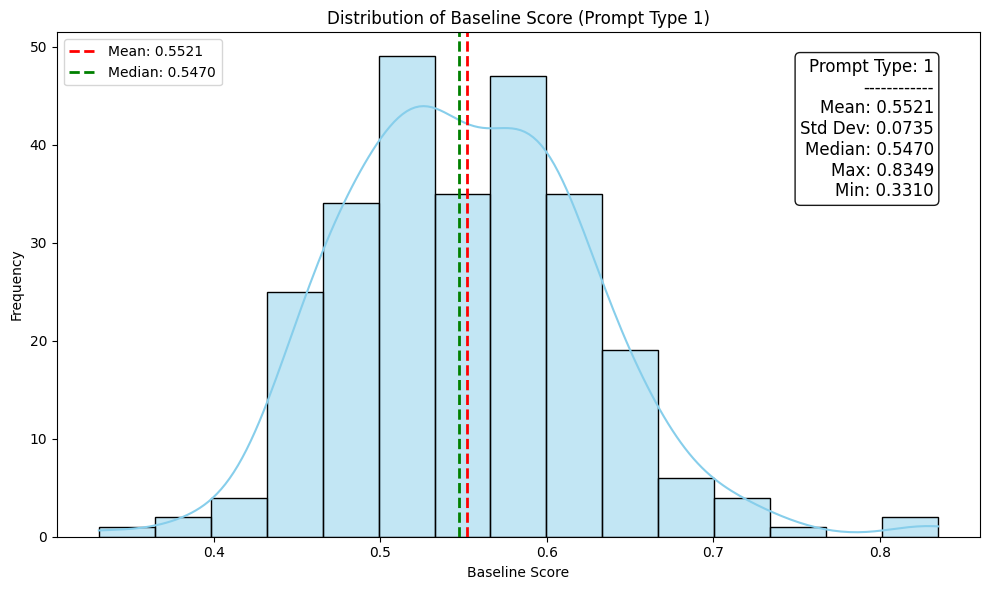

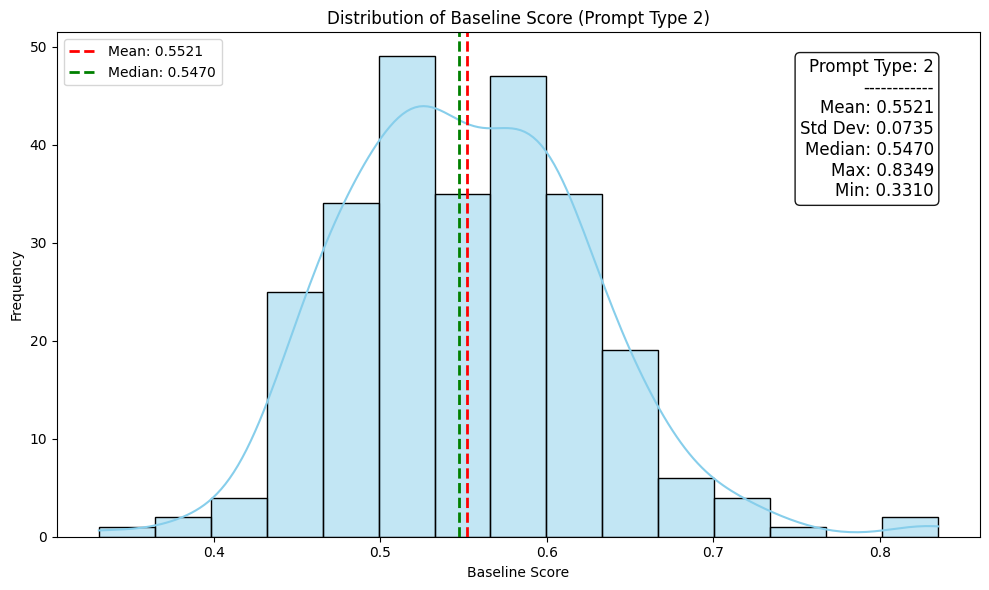

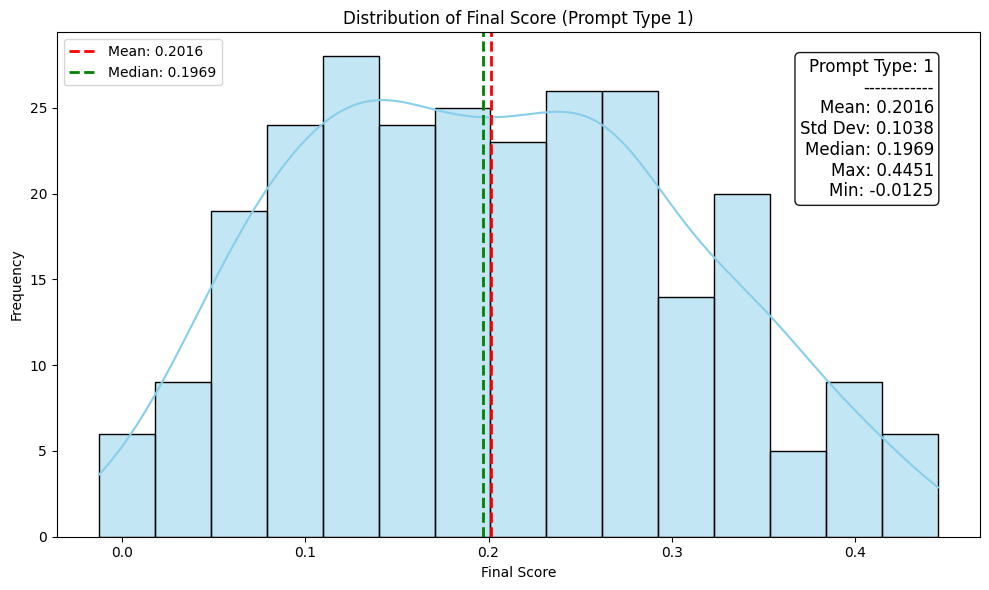

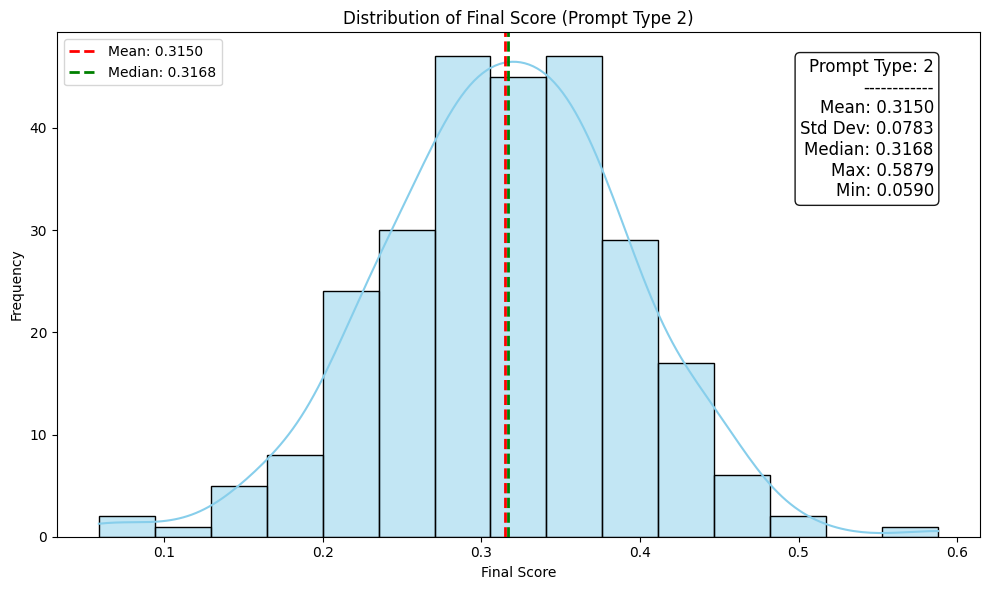

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_filtered_distribution(dataframe, column_name, prompt_type):
    """
    Filters the DataFrame by 'Prompt Type' and plots the distribution of a 
    specified column, displaying key statistics.
    
    Parameters:
    dataframe (pd.DataFrame): The DataFrame containing the data.
    column_name (str): The name of the column to plot (e.g., 'Final Score').
    prompt_type (int): The prompt type to filter by (e.g., 1 or 2).
    """
    # Validate columns
    if column_name not in dataframe.columns:
        raise ValueError(f"Column '{column_name}' not found in the dataframe.")
    if 'Prompt Type' not in dataframe.columns:
        raise ValueError("Column 'Prompt Type' not found in the dataframe.")
    
    # Filter the data based on the selected prompt type
    filtered_df = dataframe[dataframe['Prompt Type'] == prompt_type]
    
    if filtered_df.empty:
        print(f"No data found for Prompt Type {prompt_type}.")
        return
    
    # Extract the column and drop missing values
    data = filtered_df[column_name].dropna()
    
    # Calculate statistics for the filtered data
    mean_val = data.mean()
    std_val = data.std()
    median_val = data.median()
    max_val = data.max()
    min_val = data.min()
    
    # Set up the plot
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True, bins=15, color='skyblue', edgecolor='black')
    
    # Add vertical lines for mean and median
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.4f}')
    plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.4f}')
    
    # Format the statistics text
    stats_text = (
        f"Prompt Type: {prompt_type}\n"
        f"------------\n"
        f"Mean: {mean_val:.4f}\n"
        f"Std Dev: {std_val:.4f}\n"
        f"Median: {median_val:.4f}\n"
        f"Max: {max_val:.4f}\n"
        f"Min: {min_val:.4f}"
    )
    
    # Place text box in the upper-right corner of the plot
    plt.gca().text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
                   fontsize=12, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    # Labels and title
    plt.title(f'Distribution of {column_name} (Prompt Type {prompt_type})')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    
    # Display the plot
    plt.show()

# Example usage:
df = pd.read_csv('..\\results\part2_final(100)\\bert_scores.csv')
plot_filtered_distribution(df, 'Baseline Score', 1)
plot_filtered_distribution(df, 'Baseline Score', 2)

plot_filtered_distribution(df, 'Final Score', 1)
plot_filtered_distribution(df, 'Final Score', 2)